In [1]:
## standard imports
import numpy as np
import scipy
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm import tqdm

In [2]:
from scipy.stats import uniform, norm, gaussian_kde, beta, binom, Mixture
from scipy.special import gamma, logsumexp

In [3]:
!pip install dynesty

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 3.4 MB/s eta 0:00:00


In [4]:
from dynesty import NestedSampler

In [5]:
!pip install corner

In [6]:
import corner

# Beta distribution

In [7]:
p_true = 0.5
n = 10
likelihood = binom(p=p_true,n=n)
k = likelihood.rvs()
print(k)

6


In [9]:
def ptform(u):
  xmin = 0.0
  xmax = 1.0
  x = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return x

def loglike(x):
  out = binom.logpmf(k=k,n=n,p=x)[0]
  return out

In [10]:
ndim = 1
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res = sampler.results
samples = res.samples_equal()

1434it [00:01, 912.62it/s, +1000 | bound: 0 | nc: 1 | ncall: 5169 | eff(%): 58.383 | loglstar:   -inf < -1.383 <    inf | logz: -2.427 +/-    nan | dlogz:  0.001 >  1.009]


In [13]:
dist = beta(a=k+1,b=n-k+1)
samples2 = dist.rvs(len(samples))

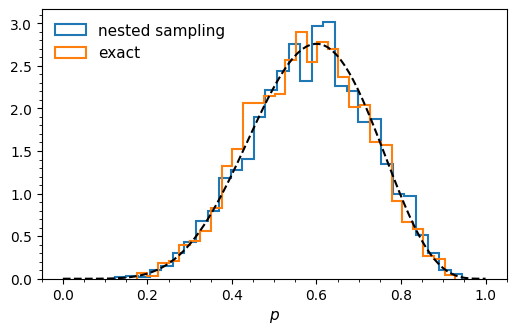

In [15]:
plt.figure(figsize=(6,3.5))

plt.hist(samples,bins=30,histtype='step',density=True,linewidth=1.5,label='nested sampling')
plt.hist(samples2,bins=30,histtype='step',density=True,linewidth=1.5,label='exact')

x = np.linspace(0,1,100)
y = dist.pdf(x)
plt.plot(x,y,color='k',linestyle='--')

plt.xlabel(r'$p$',fontsize=11)

plt.minorticks_on()

plt.legend(fontsize=11,frameon=False)

plt.show()

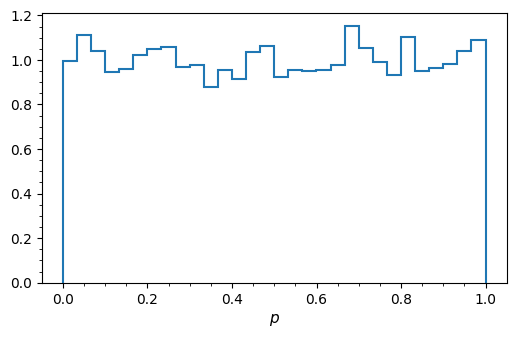

In [16]:
## note that beta(1,1)=uniform(0,1)
dist = beta(a=1,b=1)
samples3 = dist.rvs(10_000)

plt.figure(figsize=(6,3.5))

plt.hist(samples3,bins=30,histtype='step',density=True,linewidth=1.5)

plt.xlabel(r'$p$',fontsize=11)

plt.minorticks_on()

plt.show()

# Hierarchical inference (with closed-form likelihoods)

In [53]:
M = 100
n_true = np.random.randint(25,100,M)

#a_true = 1.5
#b_true = 2.5
#
#p_true = np.random.uniform(0,1,M)
#p_true = beta.rvs(a=a_true,b=b_true,size=M)
p_true = 0.5*np.ones((M))

In [54]:
k_true = np.zeros_like(p_true)
for i in range(M):
  k_true[i] = binom.rvs(p=p_true[i],n=n_true[i])

In [87]:
def ptform(u):
  #xmin = np.array([0.1,0.1])
  xmin = np.array([0.05,0.05])
  #xmax = np.array([10.0,10.0])
  xmax = np.array([0.2,0.2])
  out = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return out

def loglike(x):
  ## convenient parametrization
  #a,b = x
  a,b = 1.0/x
  out = 0.0
  for i in range(M):
    ni = n_true[i]
    ki = k_true[i]
    out += np.log(gamma(a+b)*gamma(a+ki)*gamma(ni-ki+b)/gamma(a+b+ni)/gamma(a)/gamma(b))
  return out

In [88]:
ndim = 2
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res = sampler.results
samples = res.samples_equal()

7425it [01:16, 96.66it/s, +1000 | bound: 7 | nc: 1 | ncall: 44472 | eff(%): 19.380 | loglstar:   -inf < -4220.620 <    inf | logz: -4227.964 +/-  0.092 | dlogz:  0.001 >  1.009]


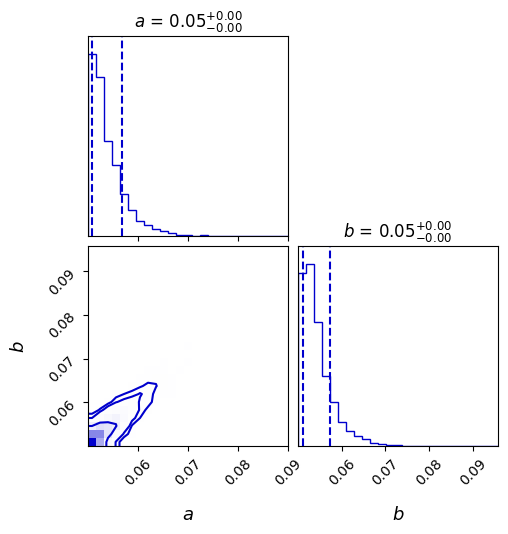

In [89]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$a$',r'$b$']
#truths = [a_true,b_true]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples,bins=25,color='mediumblue',\
                    #truths=truths,truth_color='firebrick',\
                    labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()

# Hierarchical inference (with sampled likelihoods)

In [48]:
## sample the likelihoods

n_samples = 1_00

data = []

for i in range(M):
  ki = k_true[i]
  ni = n_true[i]
  dist = beta(a=ki+1,b=ni-ki+1)
  data.append(dist.rvs(size=n_samples))

data = np.array(data)

In [49]:
def ptform(u):
  xmin = np.array([0.1,0.1])
  xmax = np.array([10.0,10.0])
  out = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return out

def loglike(x):
  a,b = x
  log_p_pop = beta(a=a,b=b).logpdf(data)
  out = np.sum(logsumexp(log_p_pop,b=1/n_samples,axis=1))
  return out

In [50]:
ndim = 2
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res2 = sampler.results
samples2 = res2.samples_equal()

5541it [02:33, 36.15it/s, +1000 | bound: 3 | nc: 1 | ncall: 40308 | eff(%): 16.640 | loglstar:   -inf < 24.884 <    inf | logz: 19.572 +/-  0.066 | dlogz:  0.001 >  1.009]


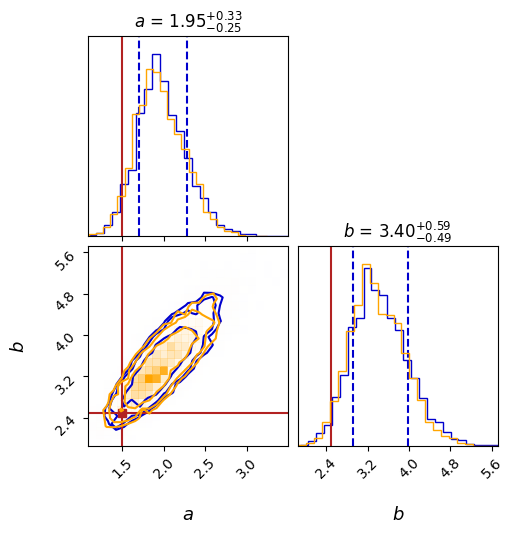

In [52]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$a$',r'$b$']
truths = [a_true,b_true]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples,bins=25,color='mediumblue',\
                    truths=truths,truth_color='firebrick',\
                    labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

corner.corner(samples2,fig=fig,bins=25,color='orange',\
                    #truths=truths,truth_color='firebrick',\
                    #labels=labels,label_kwargs={'fontsize':13},\
                    #quantiles = [0.16,0.84],\
                    #show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()

# Hierarchical inference (with sampled likelihoods and normal p_pop)

In [ ]:
## sample the likelihoods

n_samples = 1000

data = []

for i in range(M):
  ki = k_true[i]
  ni = n_true[i]
  dist = beta(a=ki+1,b=ni-ki+1)
  data.append(dist.rvs(size=n_samples))

data = np.array(data)

In [58]:
def ptform(u):
  xmin = np.array([0.,0.])
  xmax = np.array([1.0,10.0])
  out = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return out

def loglike(x):
  loc, scale = x
  log_p_pop = norm(loc=loc,scale=scale).logpdf(data)
  out = np.sum(logsumexp(log_p_pop,b=1/n_samples,axis=1))
  return out

def loglike_approx(x):
  loc, scale = x
  mu_i = k_true/n_true
  var_i = mu_i*(1-mu_i)/n_true
  out = np.sum(norm.logpdf(x=mu_i,loc=loc,scale=(scale**2+var_i)**0.5))
  return out

In [59]:
ndim = 2
nlive = 1000
sampler = NestedSampler(loglike_approx, ptform, ndim, nlive=nlive)
sampler.run_nested()
res2 = sampler.results
samples2 = res2.samples_equal()

10268it [00:44, 230.53it/s, +1000 | bound: 12 | nc: 1 | ncall: 48474 | eff(%): 23.735 | loglstar:   -inf < 122.770 <    inf | logz: 112.735 +/-  0.094 | dlogz:  0.001 >  1.009]


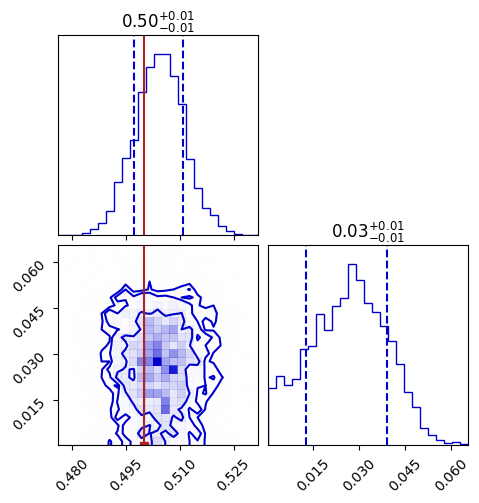

In [61]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$\mu$',r'$\sigma$']
truths = [0.5, 0.0]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples2,bins=25,color='mediumblue',\
                    truths=truths,truth_color='firebrick',\
                    #labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()

In [62]:
p_pred = norm.rvs(loc=samples2[:,0],scale=samples2[:,1])

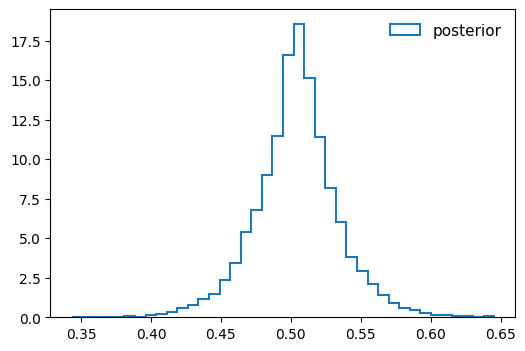

In [65]:
plt.figure(figsize=(6,4))
plt.hist(p_pred,bins=40,histtype='step',linewidth=1.5,density=True,label='posterior')

#a_true = 1
#b_true = 1

#p_pred_true = beta.rvs(a=a_true,b=b_true,size=len(samples))
#plt.hist(p_pred_true,bins=40,histtype='step',linewidth=1.5,density=True,label='true')

plt.legend(fontsize=11,frameon=False)
plt.show()

# Posterior predictive

In [90]:
p_pred = beta.rvs(a=1/samples[:,0],b=1/samples[:,1])
p_pred.shape

(8425,)

In [42]:
p_pred_true = beta.rvs(a=a_true,b=b_true,size=len(samples))

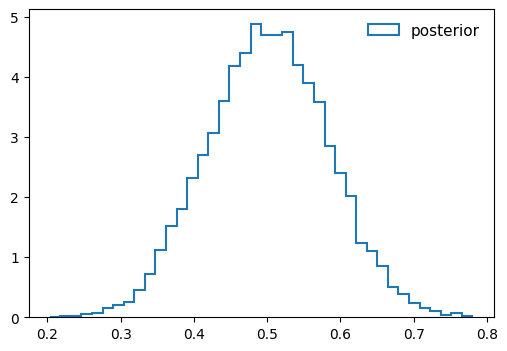

In [91]:
plt.figure(figsize=(6,4))
plt.hist(p_pred,bins=40,histtype='step',linewidth=1.5,density=True,label='posterior')
#plt.hist(p_pred_true,bins=40,histtype='step',linewidth=1.5,density=True,label='true')
plt.legend(fontsize=11,frameon=False)
plt.show()